# 8.3.2 | 드롭아웃을 이용한 성능 최적화

In [ ]:
# 8-1 라이브러리 호출
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

In [ ]:
# 8-2 데이터셋 내려받기
trainset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transforms.ToTensor())

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 303kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.49MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.8MB/s]


In [ ]:
# 8-3 데이터셋을 메모리로 가져오기
batch_size = 4
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True)

In [ ]:
dataiter = iter(trainloader)
images, labels = dataiter.__next__()

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
1


In [ ]:
# 8-5 이미지 데이터 전처리

def imshow(img, title):
  plt.figure(figsize=(batch_size*4,4))
  plt.axis('off')
  plt.imshow(np.transpose(img, (1,2,0))) # 배치크기, 채널, 너비, 높이 -> [너비, 높이, 채널]
  plt.title(title)
  plt.show()

In [ ]:
# 이미지 데이터 출력 함수
def show_batch_images(dataloader):
  images, labels = next(iter(dataloader))

  img = torchvision.utils.make_grid(images) # 좌표에 이미지 픽셀을 대응시켜 그리드 형태로 출력
  imshow(img, title=[str(x.item()) for x in labels]) # imshow 함수 사용

  return images, labels

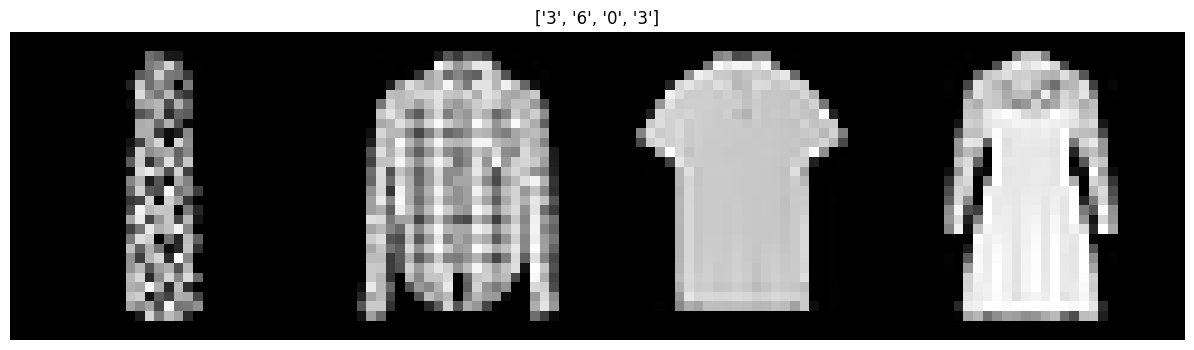

In [ ]:
images, labels = show_batch_images(trainloader)

In [ ]:
# 8-8 배치 정규화가 적용되지 않은 네트워크
class NormalNet(nn.Module):
  def __init__(self):
    super(NormalNet,self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784,48),
        nn.ReLU(),
        nn.Linear(48,24),
        nn.ReLU(),
        nn.Linear(24,10)
    )

  def forward(self,x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

In [ ]:
# 8-9 배치 정규화가 포함된 네트워크
class BNNet(nn.Module):
  def __init__(self):
    super(BNNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784,48),
        nn.BatchNorm1d(48),
        nn.ReLU(),
        nn.Linear(48,24),
        nn.BatchNorm1d(24),
        nn.ReLU(),
        nn.Linear(24,10)
    )
  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

In [ ]:
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [ ]:
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [ ]:
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model_bn.parameters(),lr=0.01)

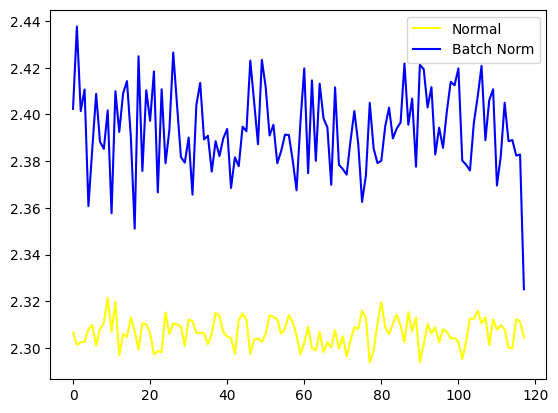

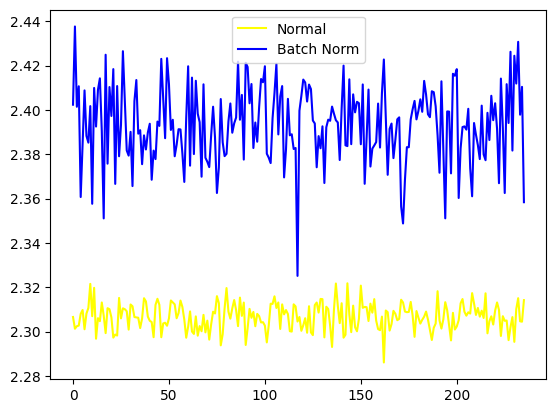

In [ ]:
# 모델 학습
loss_arr = []
loss_bn_arr = []
max_epochs=2

for epoch in range(max_epochs):
  for i,data in enumerate(trainloader, 0):
    inputs, labels = data
    opt.zero_grad()
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    opt.step()

    opt_bn.zero_grad()
    outputs_bn = model_bn(inputs)
    loss_bn = loss_fn(outputs_bn, labels)
    loss_bn.backward()
    opt_bn.step()

    loss_arr.append(loss.item())
    loss_bn_arr.append(loss_bn.item())

  plt.plot(loss_arr, 'yellow', label='Normal')
  plt.plot(loss_bn_arr, 'blue', label='Batch Norm')
  plt.legend()
  plt.show()

In [ ]:
# 8-15 데이터셋 분포를 출력하기 위한 전처리
N = 50
noise = 0.3

# 훈련 데이터셋이 -1~1의 값을 갖도록 조정함
x_train = torch.unsqueeze(torch.linspace(-1,1,N),1)
# 훈련 데이터셋 값의 범위가 정규분포를 갖도록 조정
y_train = x_train+noise*torch.normal(torch.zeros(N,1), torch.ones(N,1))

x_test = torch.unsqueeze(torch.linspace(-1,1,N), 1)
y_test = x_test + noise*torch.normal(torch.zeros(N,1), torch.ones(N,1))

* torch.linspace:주어진 범위에서 균등한 값을 갖는 텐서를 만들기 위해 사용
* torch.unsqueeze: 차원을 늘리기 위해 사용
* torch.normal: 정규분포로부터 무작위 표본을 추출

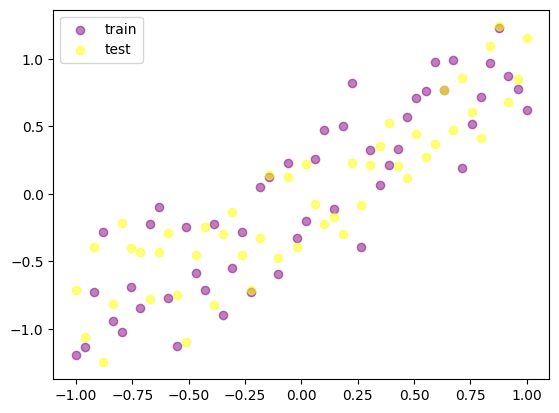

In [ ]:
# 8-16 데이터 분포를 그래프로 출력
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
            alpha=0.5, label='train')
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
            alpha=0.5,label='test')
plt.legend()
plt.show()
# alpha: 마커의 투명도 (1일때 불투명)

In [ ]:
# 8-17 드롭아웃을 위한 모델 생성
N_h=100

model = torch.nn.Sequential( # 드롭아웃 적용 X
    torch.nn.Linear(1,N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,1),
)

model_dropout = torch.nn.Sequential( # 드롭아웃 적용 O
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
)

In [ ]:
opt = torch.optim.Adam(model.parameters(), lr=0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

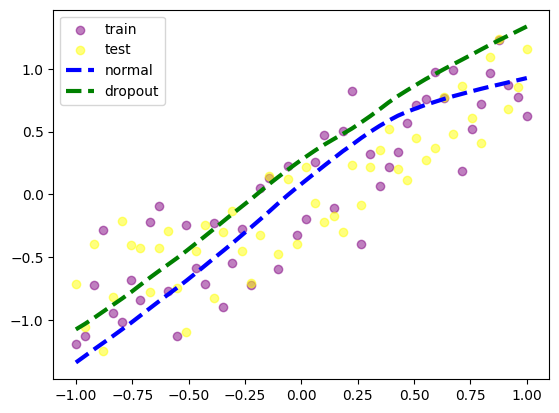

In [ ]:
# 모델 학습
max_eopchs = 1000
for epoch in range(max_epochs):
  pred = model(x_train)
  loss = loss_fn(pred, y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()

  pred_dropout = model_dropout(x_train)
  loss_dropout = loss_fn(pred_dropout, y_train)
  opt_dropout.zero_grad()
  loss_dropout.backward()
  opt_dropout.step()

  if epoch % 50 == 0:# epoch를 50으로 나눈 나머지가 0이면
    model.eval()
    model_dropout.eval()

    test_pred = model(x_test)
    test_loss = loss_fn(test_pred, y_test)

    test_pred_dropout = model_dropout(x_test)
    test_loss_dropout = loss_fn(test_pred_dropout, y_test)

    plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
                alpha=0.5, label='train')
    plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
                alpha=0.5, label='test')
    plt.plot(x_test.data.numpy(), test_pred.data.numpy(),'b--',lw=3,
             label = 'normal')
    plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(),'g--',lw=3,
             label = 'dropout')
    plt.legend()
    model.train()
    model_dropout.train()
    plt.pause(0.05)

# 8.3.3 조기 종료를 이용한 성능 최적화

In [ ]:
# prompt: 구글드라이브 마운트

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# prompt: 구글 드라이브 파일을 unzip하고 폴더에 저장

import zipfile
import os

# Define the path to the zip file in your Google Drive
zip_file_path = '/content/drive/MyDrive/EURONE/archive.zip' # Replace with your actual zip file path

# Define the directory where you want to extract the files
extract_dir = '/content/drive/MyDrive/EURONE' # Replace with your desired extraction directory

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"File '{zip_file_path}' unzipped to '{extract_dir}' successfully.")

File '/content/drive/MyDrive/EURONE/archive.zip' unzipped to '/content/drive/MyDrive/EURONE' successfully.


In [ ]:
# 8-20 라이브러리 호출
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time

import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot') # 출력 그래프에서 격자로 숫자 범위가 눈에 잘 띄도록 하는 스타일
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# 데이터셋 전처리
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# 데이터셋 가져오기
train_dataset = datasets.ImageFolder(
    root='data/hymenoptera_data/train',
    transform=train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True
)
val_dataset = datasets.ImageFolder(
    root='data/hymenoptera_data/val',
    transform=val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=32, shuffle=False,
)

In [ ]:
# 모델 생성
def resnet50(pretrained_True, requiers_grad=False):
  model = models.resnet50(progress=True, pretrained=pretrained)
  if requires_grad == False:
    for param in model.parameters():
      param.requires_grad = False
  elif requiers_grad == True:
    for param in model.parameters():
        param.requires_grad = True

  model.fc = nn.Linear(2048, 2)
  return model

In [ ]:
# 학습률 감소
class LRScheduler():
  def __init__(
      self, optimizer, patience=5, min_lr=1e-6, factor=0.5
  ):
    self.optimizer=optimizer
    self.patience=patience
    self.min_lr = min_lr
    self.factor = factor
    self.lr_scheduler=torch.optim.lr_scheduler.ReduceLDOnPlateau(
        self.optimizer,
        mode='min',
        patience=self.patience,
        factor=self.factor,
        min_lr = self.min_lr,
        verbose=True
    )
  def __call__(self, val_loss):
    self.lr_scheduler.step(val_loss)

In [ ]:
class EarlyStoppng():
  def __init__(self, patience=5, verbose=False, delta=0,
               path='path'):
    # patience : 오차 개선이 없는 에포크를 얼마나 기다릴지 결정: 5번 지속 후 종료
    # delta: 오차가 개선되고 있다고 판단하기 위한 최소 변화량
    self.patience = patience
    self.verbose = verbose
    self.counter=0
    self.best_score=None
    self.early_stop=False
    self.val_loss_min =np.Inf
    self.delta = delta
    self.path = path
  def __call__(self, val_loss, model):
    score=-val_loss
    if self.best_score=None:
      self.best_score=score
      self.save_caheckpoint(val_loss, model)
    elif score<self.best_score + self.delat:
      self.counter+=1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter>=self.patience:
        self.early_stop = True
      else:
        self.best_score=score
        self.svae_checkpoint(val_loss, model)
        self.counter=0
    def save_checkpoint(self, val_loss, model):
      if self.verbose:
        print(f'Validation loss decreased({self.val_loss_min:6f}-->{val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [ ]:
# 8.26 인수 값 지정
parser = argparse.ArgumentParser() # 인수 값을 받을 수 있는 인스턴스 생성
parser.add_argument('--lr-scheduler', dest='lr_scheduler', action='store_true')
parser.add_argument('--early-stopping', dest='early_stopping', action='store_true')
args = vars(parser.parse_args())

# parser.add_argument() : 원하는 인수 값을 추가
# 첫 파라미터: 옵션 문자열의 이름으로 명령을 실행할 때 사용
# dest: 입력 값이 저장되는 변수 - lr_scheduler
# action: store_true로 지정-> 입력값을 dest 파라미터에 의해 생성된 변수에 저장

In [ ]:
# 8-27 사전 훈련된 모델의 파라미터 확인
print(f"Computation device: {device}\n")
model = models.resnet50(pretrained=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

In [ ]:
lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

In [ ]:
loss_plot_name = 'loss'
acc_plot_name = 'accuaracy'
model_name = 'model'

In [ ]:
if args['lr_scheduler']:
  print('INFO: Initializing learning rate scheduler')
  lr_scheduler = LRScheduler(optimizer)
  loss_plot_name = 'lrs_loss'
  acc_plot_name = 'lrs_accuracy'
  model_name = 'lrs_model'
if args['early_stopping']:
  print('INFO: Initializing early stopping')
  early_stopping = EarlyStoppng()
  loss_plot_name = 'es_loss'
  acc_plot_name = 'es_accuracy'
  model_name = 'es_model'

In [ ]:
# 8-31 모델 학습 하무
def training(model, train_dataloader, train_dataset, optimizer, criterion):
  print('Training')
  model.train()
  train_running_loss=0.0
  train_running_correct=0
  counter=0
  total=0
  prog_bar = tqdm(enumerate(train_dataloader), total= int(len(train_dataset)/train_dataloader.batch_size))

  for i, data in prog_bar:
  counter += 1
  data, target = data[0].to(device), data[1].to(device)
  total+= target.size(0)
  optimizer.zero_grad()
  outputs=model(data)
  loss = criterion(outputs, target)
  train_running_loss += loss.item()
  _, preds = torch.max(outputs.data,1)
  train_running_correct += (preds ==target).sum().item()
  loss.backward()
  optimizer.step()

train_loss = train_running_loss / counter
train_accuracy = 100*train_running_correct/total
retrun train_loss, train_accuracy

In [ ]:
# 8-32 모델 검증 함수
def validate(model, test_dataloader, val_dataset, criterion):
  print('Validation')
  model.eval()
  val_running_loss=0.0
  val_running_correct=0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(test_dataloader), total= int(len(val_dataset)/test_dataloader.batch_size))

  with torch.no_grad():
    for i, data in prog_bar:
      counter+=1
      data, target = data[0].to(device), data[1].to(device)
      total+= target.size(0)
      outputs = model.(data)
      loss = criterion(outputs, target)

      val_running_loss += loss.item()
      _, preds = torch.max(outputs.data,1)
      val_running_correct += (preds ==target).sum().item()

    val_loss = val_running_loss/counter
    val_accuracy = 100. * val_running_correct/total
    return val_loss, val_accuracy

In [ ]:
# 8-33 모델 학습
train_loss, train_accuracy = [],[]
val_loss, val_accuracy = [],[]
start = time.time()

for epoch in range(epochs):
  print(f"Epoch {epoch+1} of {epochs}")
  train_epoch_loss, train_epoch_accuracy = training(model, train_dataloader,
                                                    train_dataset, optimizer, criterion)
  val_epoch_loss, val_epoch_accuracy = validate(model, val_dataloader, val_dataset, criterion)
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']:
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']:
    early_stopping(val_epoch_loss, model)
    if early_stopping.early_stop:
      break
  print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
  end = time.time()
  print(f"Training time: {(end-start)/60:.3f}minutes")

In [ ]:
# 8-34 모델 학습 결과 출력
plt.figure(figsize=(10,7))
plt.plot(train_accuracy, color='orange', label='train accuracy')
plt.plot(val_accuracy, color='orange', label='val accuracy')\
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f"{acc_plot_name}.png")
plt.show()

plt.figure(figsize=(10,7))
plt.plot(train_loss, color='blue', label='train loss')
plt.plot(val_loss, color='blue', label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"{acc_plot_name}.png")
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f"{model_name}.pt")
print('TRAINING COMPLETE')